In [5]:
!pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 707.4 kB/s eta 0:01:02
   ---------------------------------------- 0.5/44.0 MB 707.4 kB/s eta 0:01:02
    --------------------------------------- 0.8/44.0 MB 684.9 kB/s eta 0:01:04
    --------------------------------------- 0.8/44.0 MB 684.9 kB/s eta 0:01:04
    --------------------------------------- 1.0/44.0 MB 696.3 kB/s eta 0:01:02
   - -------------------------------------- 1.3/44.0 MB 717.8 kB/s eta 0:01:00
   - -------------------------------------- 1.3/44.0 MB 717.8 kB/s eta 0:01:00
   - -------------------------------------- 1.6/44.0 MB 767.2 kB/s eta 0:00:56
   - -------------------------------------- 1.8/44.0 MB 815.6 kB/s eta 0:00:52
   - -------------------------------------- 2.1/44.0 MB 847.2 kB/s eta 0:00:50


In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import warnings
warnings.filterwarnings("ignore")

In [8]:
os.chdir(r"/Users/Sanya/Desktop/data")

In [9]:
os.getcwd()

'C:\\Users\\Sanya\\Desktop\\data'

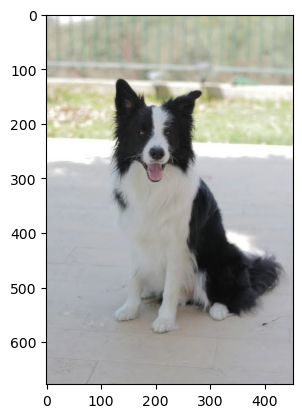

In [27]:
img = image.load_img("training/dog/3.jpeg")
plt.imshow(img)

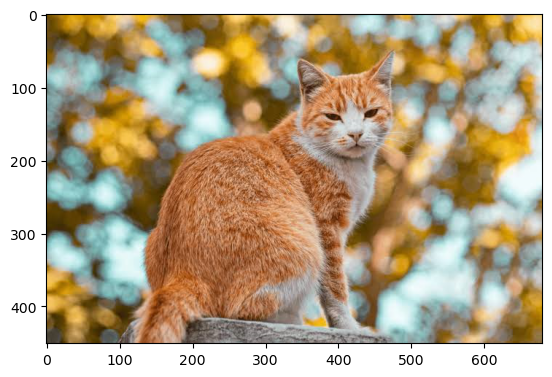

In [28]:
img = image.load_img("testing/1.jpeg")
plt.imshow(img)

In [29]:
train = ImageDataGenerator(rescale= 1/255)
validation = ImageDataGenerator(rescale= 1/255)

In [42]:
tr_location = r"C:\Users\Sanya\Desktop\data\training"
val_location = r"C:\Users\Sanya\Desktop\data\validation"

In [43]:
train_data = train.flow_from_directory(tr_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "binary")
valid_data = validation.flow_from_directory(val_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "binary")

Found 9 images belonging to 2 classes.
Found 5 images belonging to 2 classes.


In [44]:
train_data.class_indices

{'cat': 0, 'dog': 1}

In [45]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(16,(3,3),activation="relu",input_shape=(200,200,3)),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3), activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512,activation="relu"),

    tf.keras.layers.Dense(1,activation="sigmoid")])

In [46]:

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 198, 198, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 99, 99, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 97, 97, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 46, 46, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 33856)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │      17,334,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,358,881 (66.22 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(loss = "binary_crossentropy", optimizer= RMSprop(learning_rate= 0.001),
             metrics=["accuracy"])

In [48]:
model.fit(train_data,steps_per_epoch=3, epochs= 10 , validation_data=valid_data)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5556 - loss: 4.7593 - val_accuracy: 0.6000 - val_loss: 0.6020
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 349ms/step - accuracy: 0.5556 - loss: 1.3334 - val_accuracy: 0.6000 - val_loss: 0.6636
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 319ms/step - accuracy: 0.6667 - loss: 1.3917 - val_accuracy: 0.6000 - val_loss: 0.5863
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 361ms/step - accuracy: 0.5556 - loss: 0.6541 - val_accuracy: 1.0000 - val_loss: 0.5418
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 334ms/step - accuracy: 1.0000 - loss: 0.4269 - val_accuracy: 0.8000 - val_loss: 0.4031
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 327ms/step - accuracy: 0.7778 - loss: 0.3894 - val_accuracy: 1.0000 - val_loss: 0.2472
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 330ms/step - accuracy: 1.0000 - loss: 0.2252 - val_accuracy: 0.8000 - val_loss: 0.2855
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 370ms/step - accuracy: 1.0000 - loss: 0.1396 - val_accuracy: 1.0000 - val_loss: 0.

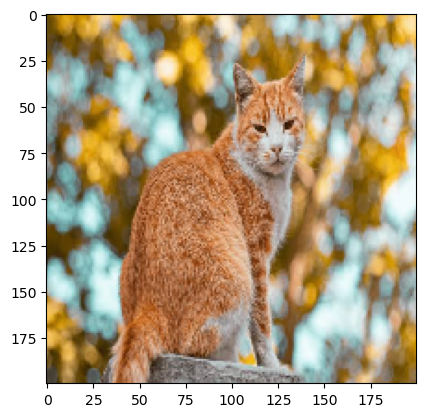

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
cat


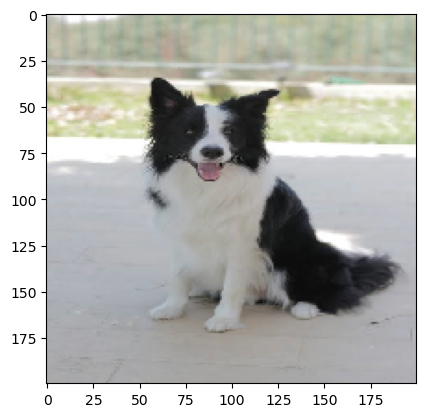

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
Dog


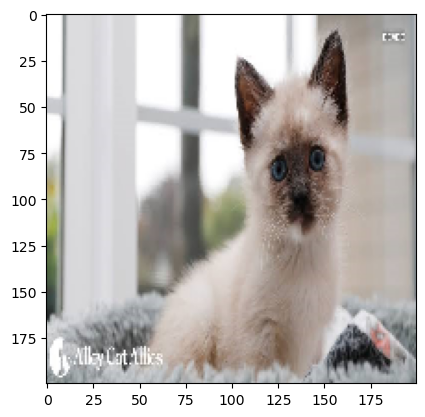

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
cat


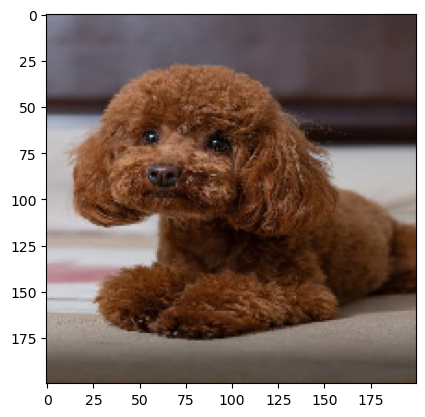

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Dog


In [50]:
path = r"/Users/Sanya/Desktop/data/testing"
for i in os.listdir(path):
    img = image.load_img(path+"/"+i,target_size=(200,200))
    plt.imshow(img)
    plt.show()
    
    x = image.img_to_array(img)
    x = np.expand_dims(x,axis = 0)
    pic = np.vstack([x])
    val = model.predict(pic)
    if val==0:
        print("cat")
    else:
        print("Dog")